
## Step 1: Reading the data

1. Go to [https://www.kaggle.com/c/titanic/data](https://www.kaggle.com/c/titanic/data)
2. If you scroll down the page a bit, you'll see a data dictionary explaining each of the columns. Take a minute to familiarize yourself with how the csv is structured.
4. Download the `train.csv` file into this lab folder.
3. Create an iPython notebook and load the csv into pandas.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Load libraries
titanic = pd.read_csv('train.csv')

In [3]:
#Load data in dataframe
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
titanic.shape

(891, 12)

In [6]:
survived = titanic[titanic['Survived']==1]

In [7]:
survived.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [8]:
survived_not = titanic[titanic['Survived']==0]

In [9]:
survived_not.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S


In [10]:
#Find the average age of those who survived and those who did not
survived['Age'].mean() # average age of those who survived

28.343689655172415

In [11]:
survived_not['Age'].mean() # average age of those who did not survived

30.62617924528302


## Step 2: Cleaning the data
1. Create a bar chart showing how many missing values are in each column
  - *Bonus* : Theres a good library for visualizing missing values called Missingno.
      - [Install Instructions](https://pypi.org/project/missingno/)
      - [Usage Documentation](https://github.com/ResidentMario/missingno)
2. Which column has the most `NaN` values? How many cells in that column are empty?
3. Delete all rows where `Embarked` is empty
4. Fill all empty cabins with **¯\\_(ツ)_/¯**

Note: `NaN`, empty, and missing are synonymous.

In [12]:
titanic.info()

# cabin has the most NaN values. 
# number of columns empty are 891 - 204 = 687

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
print(891-204)

687


In [14]:
titanic['Embarked'].value_counts(dropna=False) #default dropna=True

S      644
C      168
Q       77
NaN      2
Name: Embarked, dtype: int64

In [15]:
print(644+168+77)

889


In [16]:
Embarked_nona = titanic.loc[titanic['Embarked'].notnull(),:]

In [17]:
Embarked_nona

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [18]:
Embarked_nona['Embarked'].value_counts(dropna=False) 
# no more rows under Embarked column with missing values
# this dataframe under variable 'Embarked_nona'

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [19]:
# assigned new dataframe variable 
Cabin_emoji = Embarked_nona.fillna(value={'Cabin':'¯\(ツ)/¯'})

In [20]:
Cabin_emoji.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,¯\(ツ)/¯,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,¯\(ツ)/¯,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,¯\(ツ)/¯,S


In [21]:
# export file to see what it looked like index = False vs. index = True
Cabin_emoji.to_csv('Cabin_emoji.csv', index=False)

In [22]:
Cabin_emoji.to_csv('Cabin_emoji_index.csv', index=True)

## Step 3: Feature extraction
1.  There are two columns that pertain to how many family members are on the boat for a given person. Create a new column called `FamilyCount` which will be the sum of those two columns.
2. Reverends have a special title in their name. Create a column called `IsReverend`: 1 if they're a preacher, 0 if they're not.
3. In order to feed our training data into a classification algorithm, we need to convert our categories into 1's and 0's using `pd.get_dummies`
  - Familiarize yourself with the [`pd.get_dummies` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)
  - Create 3 columns: `Embarked_C`, `Embarked_Q` and `Embarked_S`. These columns will have 1's and 0's that correspond to the `C`, `Q` and `S` values in the `Embarked` column
  - Do the same thing for `Sex`
  - BONUS: Extract the title from everyone's name and create dummy columns

In [23]:
Cabin_emoji['FamilyCount'] = Cabin_emoji['SibSp'] + Cabin_emoji['Parch']

In [24]:
Cabin_emoji.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyCount
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,¯\(ツ)/¯,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,¯\(ツ)/¯,S,3
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C,0
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,¯\(ツ)/¯,Q,0


In [25]:
def isrev(string):
    if 'Rev' in string:
        return '1'
    else:
        return '0'
    
Cabin_emoji['IsReverend'] = Cabin_emoji['Name'].apply(isrev)

In [26]:
Cabin_emoji.to_csv('Cabin_emoji_rev.csv', index=False)

In [27]:
Cabin_emoji.loc[Cabin_emoji['IsReverend']=='1', ['PassengerId','Name','IsReverend']]

,PassengerId,Name,IsReverend
149,150,"Byles, Rev. Thomas Roussel Davids",1
150,151,"Bateman, Rev. Robert James",1
249,250,"Carter, Rev. Ernest Courtenay",1
626,627,"Kirkland, Rev. Charles Leonard",1
848,849,"Harper, Rev. John",1
886,887,"Montvila, Rev. Juozas",1


In [28]:
type(Cabin_emoji['Embarked'])

pandas.core.series.Series

In [29]:
Embarked_subset = pd.get_dummies(Cabin_emoji['Embarked'], prefix='Embarked')

In [30]:
Embarked_subset

,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1
...,...,...,...
886,0,0,1
887,0,0,1
888,0,0,1
889,1,0,0


In [31]:
# join Embarked_subset and main dataframe together
Cabin_emoji2 = pd.concat([Cabin_emoji, Embarked_subset], axis=1) 

## Cabin_emoji2 contains Embarked subsets version

In [32]:
Cabin_emoji2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyCount,IsReverend,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,¯\(ツ)/¯,S,1,0,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,0,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,¯\(ツ)/¯,S,0,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,¯\(ツ)/¯,S,0,0,0,0,1


In [33]:
Gender_subset = pd.get_dummies(Cabin_emoji2['Sex'], prefix='Sex')

In [34]:
Gender_subset

,Sex_female,Sex_male
0,0,1
1,1,0
2,1,0
3,1,0
4,0,1
...,...,...
886,0,1
887,1,0
888,1,0
889,0,1


## Cabin_emoji3 contains Gender subsets version

In [35]:
Cabin_emoji3 = pd.concat([Cabin_emoji2, Gender_subset], axis=1) 

In [36]:
Cabin_emoji3.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyCount,IsReverend,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,¯\(ツ)/¯,S,1,0,0,0,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,0,1,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,¯\(ツ)/¯,S,0,0,0,0,1,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,0,0,0,1,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,¯\(ツ)/¯,S,0,0,0,0,1,0,1


## Extract title from names, create dummy columns

In [37]:
def title(string):
    if 'Mr.' in string:
        return 'Mr'
    if 'Mrs.'in string:
        return 'Mrs'
    if 'Miss.' in string:
        return 'Miss'
    if 'Master.' in string:
        return 'Master'
    if 'Rev.' in string:
        return 'Reverend'
    if 'Don.' in string:
        return 'Don'
    if 'Dr.' in string:
        return 'Dr'
    if 'Mme.' in string:
        return 'Madame'
    if 'Ms.' in string:
        return 'Ms'
    if 'Major.' in string:
        return 'Major'
    if 'Lady.' in string:
        return 'Lady'
    if 'Sir.' in string:
        return 'Sir'
    if 'Mlle.' in string:
        return 'Mademoiselle'
    if 'Col.' in string:
        return 'Colonel'
    if 'Capt.' in string:
        return 'Captain'
    if 'Countess.' in string:
        return 'Countess'
    if 'Jonkheer.' in string:
        return 'Jonkheer'
    else: 
        return 'no title'

Cabin_emoji3['Title'] = Cabin_emoji3['Name'].apply(title)

In [38]:
# to check if missed anyone out
Cabin_emoji3.loc[Cabin_emoji3['Title']=='no title', ['PassengerId','Name','Title']]

,PassengerId,Name,Title


In [39]:
Title_subset = pd.get_dummies(Cabin_emoji3['Title'], prefix='Title')

In [40]:
Title_subset.head()

,Title_Captain,Title_Colonel,Title_Countess,Title_Don,Title_Dr,Title_Jonkheer,Title_Lady,Title_Madame,Title_Mademoiselle,Title_Major,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Ms,Title_Reverend,Title_Sir
0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [41]:
# join Title_subset and latest dataframe 'Cabin_emoji3' together
Cabin_emoji4 = pd.concat([Cabin_emoji3, Title_subset], axis=1) 

In [42]:
Cabin_emoji4.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Madame,Title_Mademoiselle,Title_Major,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Ms,Title_Reverend,Title_Sir
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,0,0,0,0,0,1,0,0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,0,0,0,0,0,0,1,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,0,0,0,0,1,0,0,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,0,0,0,0,0,0,1,0,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,0,0,0,0,0,1,0,0,0,0


In [43]:
# export final dataframe
Cabin_emoji4.to_csv('Cabin_emoji_4.csv', index=False)

## Step 4: Exploratory analysis 
_[`df.groupby()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html) may be very useful._

1. What was the survival rate overall?
2. Which gender fared the worst? What was their survival rate?
3. What was the survival rate for each `Pclass`?
4. Did any reverends survive? How many?
5. What is the survival rate for cabins marked **¯\\_(ツ)_/¯**
6. What is the survival rate for people whose `Age` is empty?
7. What is the survival rate for each port of embarkation?
8. What is the survival rate for children (under 12) in each `Pclass`?
9. Did the captain of the ship survive? Is he on the list?
10. Of all the people that died, who had the most expensive ticket? How much did it cost?
11. Does having family on the boat help or hurt your chances of survival?

### 1. What was the survival rate overall?

Survival rate overall was estimated 0.38.

In [44]:
# to ensure that the survivors who were solo passengers (without family on board) are included in the count
Cabin_emoji4.groupby(['Survived', 'FamilyCount'], dropna=False)['FamilyCount'].count()

Survived  FamilyCount
0         0              374
          1               72
          2               43
          3                8
          4               12
          5               19
          6                8
          7                6
          10               7
1         0              161
          1               89
          2               59
          3               21
          4                3
          5                3
          6                4
Name: FamilyCount, dtype: int64

In [45]:
# to sum total family members on board
Cabin_emoji4.groupby('Survived', dropna=False)['FamilyCount'].size()

Survived
0    549
1    340
Name: FamilyCount, dtype: int64

In [46]:
# to find out the total number of solo passengers (535)
Cabin_emoji4['FamilyCount'].value_counts(dropna=False)

0     535
1     161
2     102
3      29
5      22
4      15
6      12
10      7
7       6
Name: FamilyCount, dtype: int64

In [47]:
# double check count total 
print(535+161+102+29+22+15+12+7+6)

889


In [48]:
# Survival rate overall. 1 = survived
print(340/889)

0.38245219347581555


### 2. Which gender fared the worst? What was their survival rate?

Males fared the worst. Rate of survival was 0.19

#### alternative code: kept for future reference
Cabin_emoji4.groupby(['Survived','Sex_female', 'Sex_male'], dropna=False).size()

In [49]:
Cabin_emoji4.groupby(['Survived','Sex'], dropna=False).size()

Survived  Sex   
0         female     81
          male      468
1         female    231
          male      109
dtype: int64

In [50]:
# double checking passenger count correct
print(468+81+109+231)

889


In [51]:
# survival rate for females
print(231/(231+81))

0.7403846153846154


In [52]:
# survival rate for males
print(109/(109+468))

0.18890814558058924


### 3. What was the survival rate for each `Pclass`?

Survival rates for each ticket class:
<br>
1st class: 0.63
<br>
2nd class: 0.47
<br>
3rd class: 0.24

In [53]:
Cabin_emoji4.groupby(['Survived','Pclass'], dropna=False).size()

Survived  Pclass
0         1          80
          2          97
          3         372
1         1         134
          2          87
          3         119
dtype: int64

In [54]:
# survival rate for Pclass 1 (1st class) 
print(134/(134+80))

0.6261682242990654


In [55]:
# survival rate for Pclass 2 (2nd class)
print(87/(87+97))

0.47282608695652173


In [56]:
# survival rate for Pclass 3 (3rd class)
print(119/(119+372))

0.24236252545824846


### 4. Did any reverends survive? How many?

None survived

In [57]:
# no reverends survived
Cabin_emoji4.groupby(['Survived','Title_Reverend'], dropna=False).size()

Survived  Title_Reverend
0         0                 543
          1                   6
1         0                 340
dtype: int64

## 5. What is the survival rate for cabins marked ¯\(ツ)/¯

In [58]:
Cabin_emoji4.groupby(by=['Survived', 'Cabin'], dropna=False).size()

Survived  Cabin  
0         A10          1
          A14          1
          A19          1
          A24          1
          A32          1
                    ... 
1         F2           2
          F33          3
          F4           2
          G6           2
          ¯\(ツ)/¯    206
Length: 164, dtype: int64

# binning values in Cabin column
def cabin_grp(cabin):
    if cabin != '¯\(ツ)/¯':
        return 'known'
    else:
        return 'emoji'
    
Cabin_emoji4['Cabin_grp'] = Cabin_emoji4['Cabin'].apply(cabin_grp)

In [59]:
# another simpler option is filter out dataframe containing emoji
cabin_na_df = Cabin_emoji4[ Cabin_emoji4['Cabin'].isin(['¯\(ツ)/¯'])]

In [60]:
cabin_na_df[['Survived', 'Cabin']].head()

,Survived,Cabin
0,0,¯\(ツ)/¯
2,1,¯\(ツ)/¯
4,0,¯\(ツ)/¯
5,0,¯\(ツ)/¯
7,0,¯\(ツ)/¯


# checking if binning done correctly
Cabin_emoji4[['Survived', 'Cabin', 'Cabin_grp']].head()

Cabin_emoji4.groupby(by=['Survived', 'Cabin_grp'], dropna=False).size()

In [61]:
cabin_na_df.groupby(by=['Survived', 'Cabin'], dropna=False).size()

Survived  Cabin  
0         ¯\(ツ)/¯    481
1         ¯\(ツ)/¯    206
dtype: int64

# checking total
print(481+68+206+134)

In [62]:
# survival of Cabins with emoji
print(206/(481+206))

0.29985443959243085


### 6. What is the survival rate for people whose Age is empty?

In [63]:
Cabin_emoji4['Age'].info()

<class 'pandas.core.series.Series'>
Int64Index: 889 entries, 0 to 890
Series name: Age
Non-Null Count  Dtype  
--------------  -----  
712 non-null    float64
dtypes: float64(1)
memory usage: 13.9 KB


In [64]:
Cabin_emoji4.groupby(['Survived','Age'], dropna=False).size()

Survived  Age 
0         1.0      2
          2.0      7
          3.0      1
          4.0      3
          6.0      1
                  ..
1         60.0     2
          62.0     1
          63.0     2
          80.0     1
          NaN     52
Length: 144, dtype: int64

# create another column for binning age vs no age
# this one not used, found a different way that does not need to create new column
def age_grp(age):
    if pd.isna(age):
        return 'none_recorded'
    else:
        return 'age_recorded'
    
Cabin_emoji4['Age_grp'] = Cabin_emoji4['Age'].apply(age_grp)

In [65]:
# filter for age is empty
no_age_df = Cabin_emoji4[ Cabin_emoji4['Age'].isnull()]

In [66]:
no_age_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Madame,Title_Mademoiselle,Title_Major,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Ms,Title_Reverend,Title_Sir
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,...,0,0,0,0,0,1,0,0,0,0
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,...,0,0,0,0,0,1,0,0,0,0
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,...,0,0,0,0,0,0,1,0,0,0
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,...,0,0,0,0,0,1,0,0,0,0
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,...,0,0,0,0,1,0,0,0,0,0


# check binning
Cabin_emoji4[['Survived', 'Age', 'Age_grp']].head()

In [67]:
no_age_df[['Survived', 'Age']].head()

,Survived,Age
5,0,NaN
17,1,NaN
19,1,NaN
26,0,NaN
28,1,NaN


Cabin_emoji4.groupby(['Survived','Age_grp'], dropna=False).size()

In [68]:
no_age_df.groupby(['Survived'], dropna=False).size()

Survived
0    125
1     52
dtype: int64

print(424+125+288+52)

In [69]:
# survival rate for the no age group
print(52/(52+125))

0.2937853107344633


## 7. What is the survival rate for each port of embarkation?

In [70]:
# for port Southampton
Cabin_emoji4.groupby(['Survived','Embarked_S'], dropna=False).size()

Survived  Embarked_S
0         0             122
          1             427
1         0             123
          1             217
dtype: int64

In [71]:
# for port Southampton
print(217/(217+427))

0.33695652173913043


In [72]:
# for port Queenstown
Cabin_emoji4.groupby(['Survived','Embarked_Q'], dropna=False).size()

Survived  Embarked_Q
0         0             502
          1              47
1         0             310
          1              30
dtype: int64

In [73]:
# for port Queenstown
print(30/(30+47))

0.38961038961038963


In [74]:
# for port Cherbourg
Cabin_emoji4.groupby(['Survived','Embarked_C'], dropna=False).size()

Survived  Embarked_C
0         0             474
          1              75
1         0             247
          1              93
dtype: int64

In [75]:
# for port Cherbourg
print(93/(93+75))

0.5535714285714286


## 8. What is the survival rate for children (under 12) in each Pclass?

#### null values are given 12_over classification
#### This code sequence and assoc. codes not in use. Kept for future reference for alternatives
def age_under12(age):
    if age < 12:
        return 'under_12'
    else:
        return '12_over'
    
Cabin_emoji4['Under_12'] = Cabin_emoji4['Age'].apply(age_under12)

In [76]:
under12_df = Cabin_emoji4[ Cabin_emoji4['Age'] < 12]

In [77]:
under12_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Madame,Title_Mademoiselle,Title_Major,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Ms,Title_Reverend,Title_Sir
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,...,0,0,0,1,0,0,0,0,0,0
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,...,0,0,0,0,1,0,0,0,0,0
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,...,0,0,0,1,0,0,0,0,0,0
24,25,0,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,21.0750,...,0,0,0,0,1,0,0,0,0,0
43,44,1,2,"Laroche, Miss. Simonne Marie Anne Andree",female,3.0,1,2,SC/Paris 2123,41.5792,...,0,0,0,0,1,0,0,0,0,0


Cabin_emoji4[['Survived', 'Age', 'Under_12']].head(10)

In [78]:
under12_df[['Survived', 'Age']].head()

,Survived,Age
7,0,2.0
10,1,4.0
16,0,2.0
24,0,8.0
43,1,3.0


Cabin_emoji4.groupby(['Survived','Under_12', 'Pclass'], dropna=False).size()

In [79]:
under12_df.groupby(['Survived', 'Pclass'], dropna=False).size()

Survived  Pclass
0         1          1
          3         28
1         1          3
          2         17
          3         19
dtype: int64

In [80]:
# survival rate for under 12 in Pclass 1
print(3/(3+1))

0.75


In [81]:
# survival rate for under 12 in Pclass 2
print(17/(17+0))

1.0


In [82]:
# survival rate for under 12 in Pclass 3
print(19/(19+28))

0.40425531914893614


## 9. Did the captain of the ship survive? Is he on the list?

In [83]:
# captain of the ship did not survive
Cabin_emoji4.loc[ Cabin_emoji4['Title']=='Captain', ['Survived', 'Name'] ].head()

,Survived,Name
745,0,"Crosby, Capt. Edward Gifford"


## 10. Of all the people that died, who had the most expensive ticket? How much did it cost?

In [84]:
died_fare_df = Cabin_emoji4.loc[ Cabin_emoji4['Survived']==0, ['Survived','Name', 'Fare', ] ]

In [85]:
# Fortune family (Mr. Charles Alexander Fortune and Mr. Mark Fortune) had the most expensive tickets and died
died_fare_df.sort_values('Fare', ascending=False).head()

,Survived,Name,Fare
27,0,"Fortune, Mr. Charles Alexander",263.0000
438,0,"Fortune, Mr. Mark",263.0000
118,0,"Baxter, Mr. Quigg Edmond",247.5208
557,0,"Robbins, Mr. Victor",227.5250
527,0,"Farthing, Mr. John",221.7792


## 11. Does having family on the boat help or hurt your chances of survival?

In [86]:
no_family_df = Cabin_emoji4[(Cabin_emoji4['FamilyCount']==0)]

In [87]:
no_family_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Madame,Title_Mademoiselle,Title_Major,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Ms,Title_Reverend,Title_Sir
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,0,0,0,0,1,0,0,0,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,0,0,0,0,0,1,0,0,0,0
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,...,0,0,0,0,0,1,0,0,0,0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,...,0,0,0,0,0,1,0,0,0,0
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,...,0,0,0,0,1,0,0,0,0,0


In [88]:
no_family_df.groupby(['Survived','FamilyCount'], dropna=False).size()

Survived  FamilyCount
0         0              374
1         0              161
dtype: int64

In [89]:
# rate of survival for those onboard without family
print(161/(161+374))

0.30093457943925234


In [90]:
# double checking all rows accounted for
print(179+175+161+374)

889


In [91]:
with_family_df = Cabin_emoji4[(Cabin_emoji4['FamilyCount'] > 0)]

In [92]:
with_family_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Madame,Title_Mademoiselle,Title_Major,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Ms,Title_Reverend,Title_Sir
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,0,0,0,0,0,1,0,0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,0,0,0,0,0,0,1,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,0,0,0,0,0,0,1,0,0,0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,...,0,0,0,1,0,0,0,0,0,0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,...,0,0,0,0,0,0,1,0,0,0


In [93]:
with_family_df.groupby(['Survived'], dropna=False)['FamilyCount'].sum()

Survived
0    485
1    321
Name: FamilyCount, dtype: int64

In [94]:
# rate of survival for those onboard with family
print(321/(321+485))

0.39826302729528534


### Answer: higher rate of surviving if you have family on the boat

## Step 5: Plotting
Using Matplotlib and Seaborn, create several charts showing the survival rates of different groups of people. It's fine if a handful of charts are basic (Gender, Age, etc), but what we're really looking for is something beneath the surface.


In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
Cabin_emoji4.groupby(['Survived','Sex'], dropna=False).size()

Survived  Sex   
0         female     81
          male      468
1         female    231
          male      109
dtype: int64

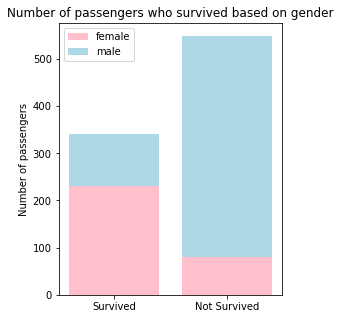

In [97]:
# selected stacked bar chart to show proportions between genders
plt.figure(figsize = (4, 5))

x = ['Survived' , 'Not Survived']
y1 = [231, 81]
y2 = [109, 468]

plt.bar(x, y1, color = 'pink')
plt.bar(x, y2, bottom=y1, color = 'lightblue')
plt.legend(["female", "male"])
plt.ylabel('Number of passengers')
plt.title("Number of passengers who survived based on gender");

<span style="color:crimson">
    From the stacked bar chart, more passengers died than survived. Out of those that survived, about 2/3 were female. 
    <br>
    <br>
    Also, survival rate for females was higher than males, since majority of females survived, and majority of males died (comparing the height proportions for the respective genders).
</span>  

In [98]:
Cabin_emoji4.groupby(['Survived','Pclass'], dropna=False).size()

Survived  Pclass
0         1          80
          2          97
          3         372
1         1         134
          2          87
          3         119
dtype: int64

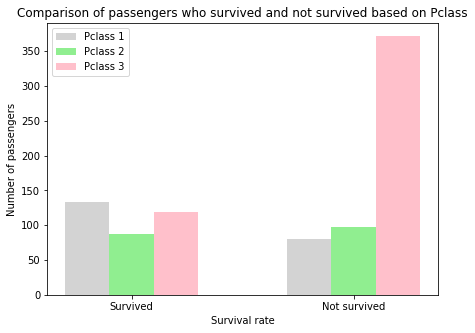

In [99]:
# selected grouped bar plot to compare 3 different groups
plt.figure(figsize = (7, 5))

x = np.arange(2)
Pclass_1 = [134, 80]
Pclass_2 = [87, 97]
Pclass_3 = [119, 372]
width = 0.2

plt.bar(x-0.2, Pclass_1, width, color='lightgray')
plt.bar(x, Pclass_2, width, color='lightgreen')
plt.bar(x+0.2, Pclass_3, width, color='pink')
plt.xticks(x, ['Survived', 'Not survived'])
plt.xlabel("Survival rate")
plt.ylabel("Number of passengers")
plt.title("Comparison of passengers who survived and not survived based on Pclass")
plt.legend(["Pclass 1", "Pclass 2", "Pclass 3"]);

<span style="color:crimson">
    Based on the bar chart above, it seems that based on numbers alone, all 3 ticket classes had similar numbers of passengers saved/survived. 
    <br>
    <br>
    However, because of the sheer number of 3rd class passengers onboard, it would seem that being a 3rd class passenger has the lowest rate of survival. 
    <br>
    <br>
    There might be a slight advantage in being a 1st class passenger, as slightly more passengers in that class survived than died. And they also have the most number of passengers out of the 3 ticket classes that survived.
</span>

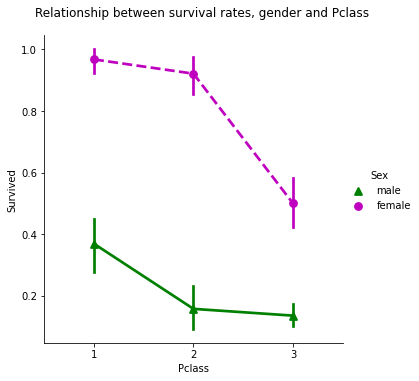

In [100]:
# seaborn pointplot
catplot1 = sns.catplot(x="Pclass", y="Survived", hue="Sex",
            palette={"male": "green", "female": "m"},
            markers=["^", "o"], linestyles=["-", "--"],
            kind="point", data=Cabin_emoji4);

catplot1.fig.suptitle("Relationship between survival rates, gender and Pclass",  y=1.05);

In [101]:
under12_df.groupby(['Survived', 'Pclass'], dropna=False).size()

Survived  Pclass
0         1          1
          3         28
1         1          3
          2         17
          3         19
dtype: int64

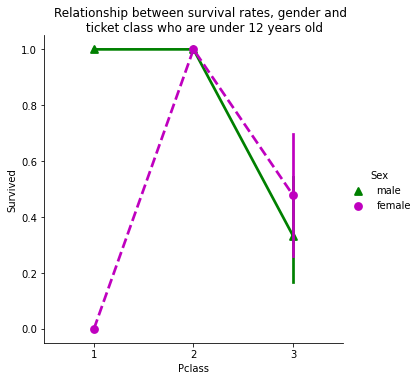

In [102]:
# seaborn pointplot
catplot2 = sns.catplot(x="Pclass", y="Survived", hue="Sex",
            palette={"male": "green", "female": "m"},
            markers=["^", "o"], linestyles=["-", "--"],
            kind="point", data=under12_df);

catplot2.fig.suptitle("Relationship between survival rates, gender and \n ticket class who are under 12 years old",  y=1.05);

<span style="color:crimson">
    Based on the point plot by Seaborn figure-level interface, it seems that there is no difference in survival rates between genders, as long as you are below 12 years old. 
    <br>
    <br>
    The outlier datapoint is due to this being a small sample size (4 children passengers in ticket 1st class, 1 female and 3 males).
</span>

In [103]:
# double checking the outlier on Pclass 1
under12_df[ (under12_df['Pclass']==1) ]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Madame,Title_Mademoiselle,Title_Major,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Ms,Title_Reverend,Title_Sir
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,...,0,0,0,0,1,0,0,0,0,0
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,...,0,0,0,1,0,0,0,0,0,0
445,446,1,1,"Dodge, Master. Washington",male,4.00,0,2,33638,81.8583,...,0,0,0,1,0,0,0,0,0,0
802,803,1,1,"Carter, Master. William Thornton II",male,11.00,1,2,113760,120.0000,...,0,0,0,1,0,0,0,0,0,0


In [104]:
# double checking the outlier on Pclass 1
under12_df[ (under12_df['Pclass']==1) & (under12_df['Survived']==0)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Madame,Title_Mademoiselle,Title_Major,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Ms,Title_Reverend,Title_Sir
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.0,1,2,113781,151.55,...,0,0,0,0,1,0,0,0,0,0


In [105]:
Cabin_emoji4.groupby(['Survived','Embarked'], dropna=False).size()

Survived  Embarked
0         C            75
          Q            47
          S           427
1         C            93
          Q            30
          S           217
dtype: int64

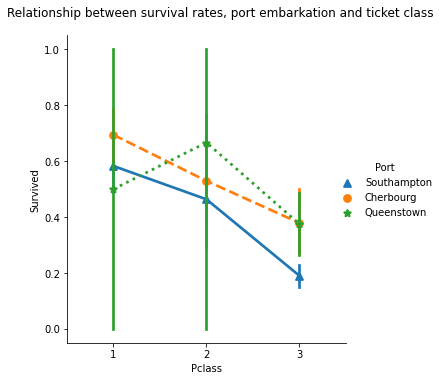

In [106]:
# seaborn pointplot
catplot3 = sns.catplot(x="Pclass", y="Survived", hue="Embarked",
            palette=sns.color_palette(),
            markers=["^", "o", "*"], linestyles=["-", "--", ':'],
            kind="point", data=Cabin_emoji4)

# to access the legend in Seaborn figure
legend = catplot3._legend 

# assign new labels and title to legend in figure instead of Embarked, S, C, Q
legend.set_title("Port")
for t, l in zip(legend.texts,('Southampton','Cherbourg', 'Queenstown')):
    t.set_text(l)
    
# adjust figure dimension on right side to increase spacing with legend
catplot3.fig.subplots_adjust(right=0.8)

# assign title to Seaborn figure
catplot3.fig.suptitle("Relationship between survival rates, port embarkation and ticket class",  y=1.05);

<span style="color:crimson">
    Based on the point plot by Seaborn figure-level interface, it seemed that passengers who boarded titanic from Southamption port may have a slightly lower rate of survival.
</span>

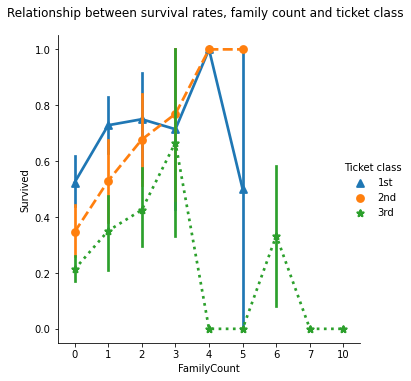

In [107]:
# seaborn pointplot
catplot4 = sns.catplot(x="FamilyCount", y="Survived", hue="Pclass",
            palette=sns.color_palette(),
            markers=["^", "o", "*"], linestyles=["-", "--", ':'],
            kind="point", data=Cabin_emoji4)

# to access the legend in Seaborn figure
legend = catplot4._legend 

# assign new labels and title to legend in figure instead of Pclass, 1, 2, 3
legend.set_title("Ticket class")
for t, l in zip(legend.texts,('1st','2nd','3rd')):
    t.set_text(l)

# assign title to Seaborn figure
catplot4.fig.suptitle("Relationship between survival rates, family count and ticket class",  y=1.05);

<span style="color:crimson">
     Based on the point plot by Seaborn figure-level interface, there are a few interesting findings.
    <br>
    <br>
1. Generally, the more family members a passenger had on board Titanic, the better the rate of survival. However, that rate drops once the number exceeds 4, then the rate of survival becomes similar or worse than those who were alone on the ship.
    <br>
    <br>
2. For smaller families (3 or less members) on board, the rate of survival seemed proportionate to the ticket class level. E.g. families in 1st class had highest rate of survival, followed by 2nd class, and 3rd class had the lowest rate of survival.
    <br>
    <br>
3. Survival rates were similar for all 3 ticket classes if they had a family size of 3. (rate around 0.7)
    <br>
    <br>
4. For families with 4 to 5 members, survival rates seemed similar between 1st and 2nd ticket classes. 
    <br>
    <br>
5. In general, it would seem that passengers with 3rd class tickets had a lower rate of survival across family group sizes.
</span>